# RiskDesk — Research Notebook

A complete, fast tour of everything discovered across this project — one section per module built, in the same order as `README.md`. Every cell calls the real modules in `riskdesk/` against real, live-fetched data (the same connectors, pricing, and analytics used throughout the rest of the project — nothing here is a separate, simplified reimplementation), and this notebook is executed end-to-end so its saved outputs are genuine current results, not placeholder code.

Re-running this notebook regenerates fresh numbers — live positions, current market prices, and current regime classification all change day to day, so exact figures will drift from this saved run and from the README's own point-in-time snapshot. That's expected. See `README.md` for full methodology disclosures, judgment calls, and limitations behind every number below; this notebook is the fast, interactive companion, not a replacement for that narrative.

In [1]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 100

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Position aggregation

Pull live positions from all six connectors, value them, and roll up net/gross exposure by strategy, asset class, and counterparty.

In [2]:
from connectors.registry import fetch_all
from aggregation.valuation import value_positions
from aggregation.rollup import portfolio_total, by_strategy, by_asset_class, by_counterparty

raw_positions, source_meta = fetch_all()
valued = value_positions(raw_positions)

for m in source_meta:
    print(f"[{m.repo}] n_positions={m.n_positions}: {m.notes}")

positions_df = pd.DataFrame([
    {"strategy": p.strategy, "asset": p.asset, "quantity": p.quantity, "market_value": p.market_value,
     "asset_class": p.asset_class.value, "counterparty": p.counterparty.value}
    for p in valued.positions
])
print(f"\n{valued.n_priced} priced, {valued.n_unpriced} unpriced")
positions_df

[alpha-signal-lab] n_positions=10: Latest snapshot 2026-08-07: equity=99599.38, cash=98221.45.
[streamalpha] n_positions=0: streamalpha has no position/portfolio concept (anomaly-detection pipeline only); excluded from position aggregation by design.
[bookmaker] n_positions=1: Most recent completed run: strategy=inventory_aware, data_source=binance_real, final_pnl=0.00021939999669484678.
[execedge] n_positions=0: execedge has no position/portfolio concept (execution-cost benchmark only); excluded from position aggregation by design. Additionally, /Users/hkbuttar/execedge/backtest/results does not exist (no persisted backtest runs).
[pairtrade-lab-1] n_positions=2: Disclosed backtest stand-in (not live): last non-flat snapshot within backtest window 2023-01-03..2024-12-31 was 2024-04-25 00:00:00; sharpe=0.053678369616789595, n_trades=11.
[voledge] n_positions=20: Disclosed stand-in (not a live position): 548 contracts flagged by voledge's own compute_signal() on the real, current SPY ch

,strategy,asset,quantity,market_value,asset_class,counterparty
0,alpha-signal-lab,CVX,26.65,"4,971.00",equity,alpaca
1,alpha-signal-lab,EOG,37.01,"4,987.23",equity,alpaca
2,alpha-signal-lab,MPC,16.98,"5,063.53",equity,alpaca
3,alpha-signal-lab,PFE,-188.00,"-5,030.88",equity,alpaca
4,alpha-signal-lab,PSX,24.62,"5,020.56",equity,alpaca
5,alpha-signal-lab,VLO,16.96,"5,059.18",equity,alpaca
6,alpha-signal-lab,AMGN,-12.00,"-4,931.34",equity,alpaca
7,alpha-signal-lab,AVGO,-12.00,"-5,133.12",equity,alpaca
8,alpha-signal-lab,INTC,-39.00,"-3,964.35",equity,alpaca
9,alpha-signal-lab,NVDA,-22.00,"-4,927.12",equity,alpaca


Portfolio: net=$-2,672.73  gross=$706,778.35


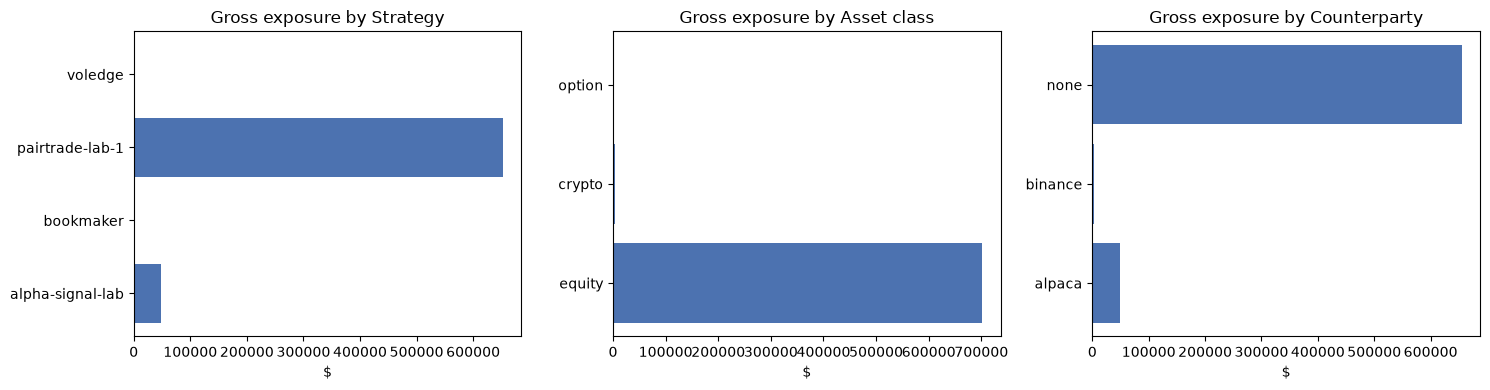

In [3]:
total = portfolio_total(valued.positions)
print(f"Portfolio: net=${total.net_market_value:,.2f}  gross=${total.gross_market_value:,.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (label, rollup_fn) in zip(axes, [("Strategy", by_strategy), ("Asset class", by_asset_class), ("Counterparty", by_counterparty)]):
    buckets = rollup_fn(valued.positions)
    names = list(buckets.keys())
    gross = [buckets[n].gross_market_value for n in names]
    ax.barh(names, gross, color="#4C72B0")
    ax.set_title(f"Gross exposure by {label}")
    ax.set_xlabel("$")
plt.tight_layout()
plt.show()

## 2. VaR/CVaR — five methods compared

Historical simulation, parametric (normal), Monte Carlo, Cornish-Fisher, and EVT (Peaks-Over-Threshold), at 95% and 99% confidence.

In [4]:
from risk_measures.returns import fetch_return_history, build_portfolio_pnl_series, position_risk_factor
from risk_measures.var import historical_simulation, parametric_variance_covariance, monte_carlo, cornish_fisher, evt_pot

tickers = sorted({position_risk_factor(p) for p in valued.positions if position_risk_factor(p)})
returns_df, _ = fetch_return_history(tickers)
pnl_series, weights, _ = build_portfolio_pnl_series(valued.positions, returns_df)

rows = []
for confidence in (0.95, 0.99):
    for name, fn in [
        ("historical_simulation", lambda p, c: historical_simulation(p, c)),
        ("parametric_normal", lambda p, c: parametric_variance_covariance(p, c)),
        ("monte_carlo", lambda p, c: monte_carlo(returns_df, weights, c)),
        ("cornish_fisher", lambda p, c: cornish_fisher(p, c)),
        ("evt_pot", lambda p, c: evt_pot(p, c)),
    ]:
        r = fn(pnl_series, confidence)
        rows.append({"method": name, "confidence": confidence, "VaR": r.var_dollar, "CVaR": r.cvar_dollar})

var_df = pd.DataFrame(rows)
var_df.pivot(index="method", columns="confidence", values="VaR")

confidence,0.95,0.99
method,,
cornish_fisher,"8,483.07","17,148.77"
evt_pot,"7,250.71","13,737.42"
historical_simulation,"7,594.01","14,077.92"
monte_carlo,"8,111.38","11,428.59"
parametric_normal,"8,114.70","11,507.62"


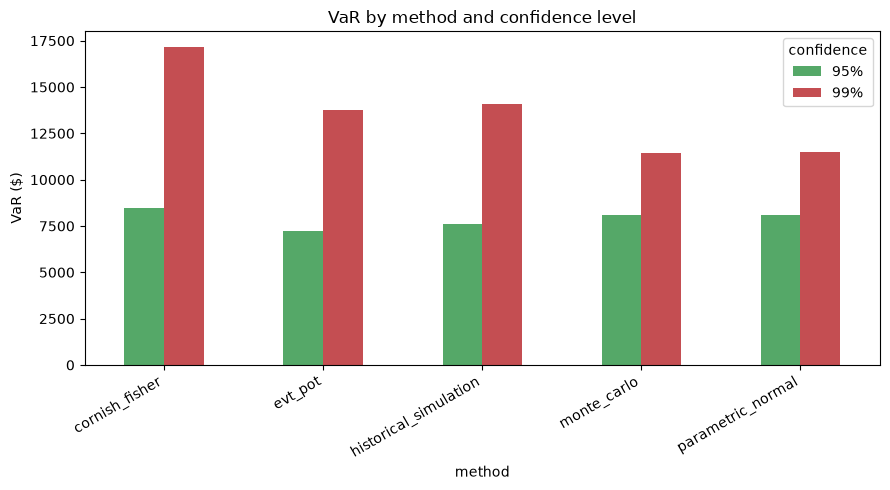

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
pivot = var_df.pivot(index="method", columns="confidence", values="VaR")
pivot.plot(kind="bar", ax=ax, color=["#55A868", "#C44E52"])
ax.set_ylabel("VaR ($)")
ax.set_title("VaR by method and confidence level")
ax.legend(title="confidence", labels=["95%", "99%"])
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 3. Correlation — static vs. DCC-GARCH, and static vs. Ledoit-Wolf

Static (whole-window) correlation vs. the latest DCC-GARCH-fitted dynamic correlation, side by side, plus the Ledoit-Wolf shrinkage condition-number improvement.

DCC params: a=0.0097, b=0.9228 (persistence a+b=0.9325); 500 days x 14 assets; optimizer: Optimization terminated successfully.
Ledoit-Wolf shrinkage=0.049: condition number 155.0 -> 60.8


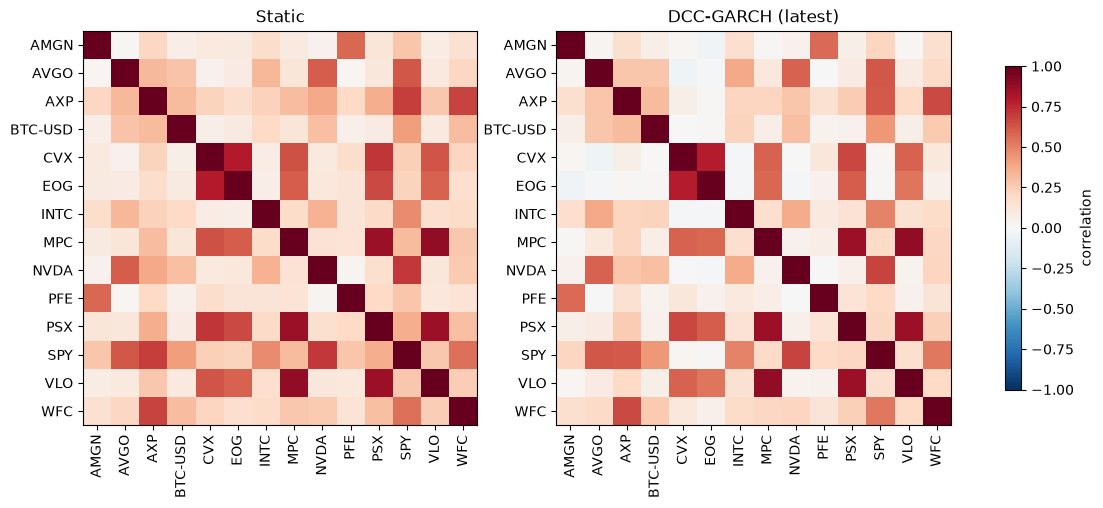

In [6]:
from correlation.static import static_correlation
from correlation.dcc_garch import fit_dcc_garch
from correlation.shrinkage import ledoit_wolf_covariance

static_corr = static_correlation(returns_df)
dcc = fit_dcc_garch(returns_df)
latest_dcc = dcc.latest_correlation()
print(dcc.notes)

lw = ledoit_wolf_covariance(returns_df)
print(f"Ledoit-Wolf shrinkage={lw.shrinkage:.3f}: condition number {lw.sample_condition_number:,.1f} -> {lw.shrunk_condition_number:,.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (title, corr) in zip(axes, [("Static", static_corr), ("DCC-GARCH (latest)", latest_dcc)]):
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticks(range(len(corr.index))); ax.set_yticklabels(corr.index)
    ax.set_title(title)
fig.colorbar(im, ax=axes, shrink=0.7, label="correlation")
plt.show()

## 4. Regime classification

Volatility-tercile (execedge's own methodology) vs. a 3-state Markov-switching model, on SPY.

/Users/hkbuttar/riskdesk/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Current tercile regime: normal
Current HMM probabilities:
calm       0.69
normal     0.31
volatile   0.00
Name: 2026-08-07 00:00:00, dtype: float64


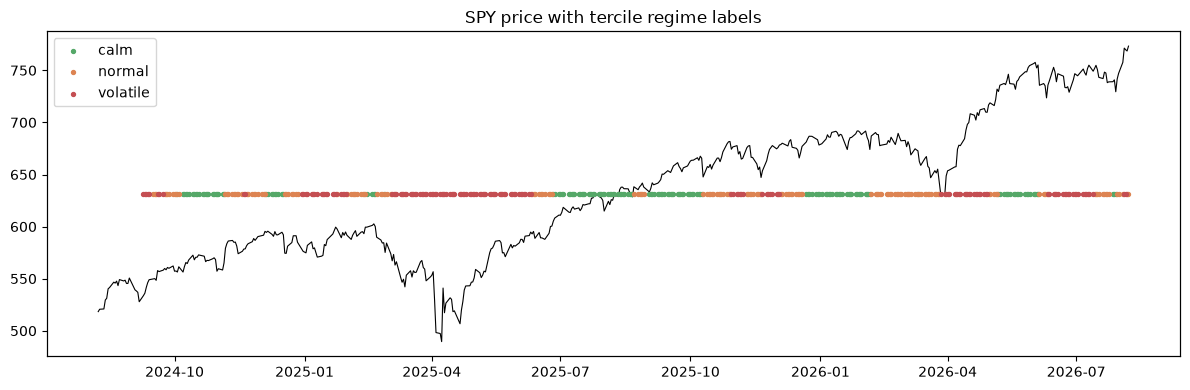

In [7]:
import connectors.alpaca_market_data as alpaca_data
from regime.volatility_tercile import classify_regimes, rolling_realized_vol
from regime.hmm_regime import fit_hmm_regimes

spy_close = alpaca_data.fetch_history(["SPY"], period="2y", field="close")["SPY"]
spy_close.index = spy_close.index.tz_localize(None)

vol = rolling_realized_vol(spy_close)
tercile = classify_regimes(vol)
hmm = fit_hmm_regimes(spy_close)

print(f"Current tercile regime: {tercile.current()}")
print(f"Current HMM probabilities:\n{hmm.current_probabilities()}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(spy_close.index, spy_close.values, color="black", linewidth=0.8)
ax2 = ax.twinx()
colors = {"calm": "#55A868", "normal": "#DD8452", "volatile": "#C44E52"}
for regime, color in colors.items():
    mask = tercile.labels == regime
    ax2.scatter(spy_close.index[mask], [0] * mask.sum(), color=color, s=8, label=regime)
ax.set_title("SPY price with tercile regime labels")
ax2.set_yticks([])
ax2.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 5. Regime-conditional VaR vs. pooled

Re-estimates VaR separately per regime (tercile labels) and compares against the single pooled model.

In [8]:
from regime.conditional import compare_pooled_vs_conditional

regime_labels = tercile.labels
conditional_result = compare_pooled_vs_conditional(pnl_series, returns_df, regime_labels)

rows = []
for method in ("historical_simulation", "parametric_normal", "cornish_fisher"):
    row = {"method": method, "pooled": conditional_result.pooled_var[method].var_dollar}
    for regime in ("calm", "normal", "volatile"):
        if regime in conditional_result.conditional_var:
            row[regime] = conditional_result.conditional_var[regime][method].var_dollar
    rows.append(row)
regime_var_df = pd.DataFrame(rows).set_index("method")
print(f"Days per regime: {conditional_result.regime_day_counts}")
regime_var_df

Days per regime: {'volatile': 160, 'normal': 160, 'calm': 160}


,pooled,calm,normal,volatile
method,,,,
historical_simulation,"7,594.01","7,975.14","6,110.22","7,602.12"
parametric_normal,"8,114.70","7,304.91","8,519.49","8,573.59"
cornish_fisher,"8,483.07","7,435.88","8,622.88","9,653.90"


## 6. Factor decomposition — the hidden-beta finding

Portfolio-level and per-strategy regression against named factors (market, sector, crypto), plus PCA as a model-free complement. This is where pairtrade-lab-1's "market-neutral" book reveals significant hidden SPY/Financials beta.

In [9]:
from factor_model.factors import fetch_factor_returns, sector_of
from factor_model.regression import fit_factor_regression
from factor_model.pca import fit_pca

sectors_held = {sector_of(t) for t in tickers if sector_of(t)}
factor_returns, _ = fetch_factor_returns(sectors_held)

portfolio_fit = fit_factor_regression("portfolio", pnl_series, factor_returns)
print(f"Portfolio R²={portfolio_fit.r_squared:.3f}")

strategy_fits = {}
for strategy in sorted({p.strategy for p in valued.positions}):
    strat_positions = [p for p in valued.positions if p.strategy == strategy]
    strat_pnl, strat_weights, _ = build_portfolio_pnl_series(strat_positions, returns_df)
    if strat_weights:
        strategy_fits[strategy] = fit_factor_regression(strategy, strat_pnl, factor_returns)

loadings_df = pd.DataFrame({s: f.loadings for s, f in strategy_fits.items()}).T
loadings_df["R²"] = [strategy_fits[s].r_squared for s in loadings_df.index]
loadings_df

Portfolio R²=0.087


,BTC-USD,SPY,XLE,XLF,XLK,XLV,R²
alpha-signal-lab,-303.51,"-3,417.35","26,035.72","6,500.00","-18,801.85","-10,685.46",0.72
bookmaker,"2,848.22",-0.00,-0.00,0.00,0.00,0.00,1.00
pairtrade-lab-1,"10,487.10","-257,322.47","5,387.51","109,531.00","49,610.12","-11,641.33",0.06
voledge,0.00,"2,203.28",-0.00,-0.00,-0.00,0.00,1.00


In [10]:
pairtrade_fit = strategy_fits.get("pairtrade-lab-1")
if pairtrade_fit:
    spy_t = pairtrade_fit.t_stats["SPY"]
    spy_p = pairtrade_fit.p_values["SPY"]
    print(f"pairtrade-lab-1 SPY loading: {pairtrade_fit.loadings['SPY']:,.0f}  t={spy_t:.2f}  p={spy_p:.4f}")
    print("-> statistically significant hidden market beta in a supposedly 'market-neutral' book"
          if spy_p < 0.05 else "-> not significant at the 5% level in this run")

pca = fit_pca(returns_df)
print(f"\nPCA: {pca.n_components_for_90pct} of {len(returns_df.columns)} components needed for 90% of variance")

pairtrade-lab-1 SPY loading: -257,322  t=-2.98  p=0.0031
-> statistically significant hidden market beta in a supposedly 'market-neutral' book

PCA: 8 of 14 components needed for 90% of variance


## 7. Greeks & options convexity

Net portfolio Greeks, and the gamma-convexity table showing how much the delta-only approximation (used everywhere else in this project) misses.

In [11]:
from aggregation.greeks import aggregate_greeks, gamma_convexity_table

greeks = aggregate_greeks(valued.positions)
print(f"Net delta: {greeks.net_delta_shares:.2f} shares (${greeks.net_delta_dollars:,.2f})")
print(f"Net gamma: {greeks.net_gamma_shares:.4f}")
print(f"Net vega:  ${greeks.net_vega:,.2f} (per 100-vol-point move)")
print(f"Net theta: ${greeks.net_theta:,.2f}/day")

convexity_df = pd.DataFrame([
    {"move": f"{r.move_pct:+.0%}", "linear": r.linear_pnl, "quadratic": r.quadratic_pnl, "gamma_correction": r.gamma_correction}
    for r in gamma_convexity_table(valued.positions)
])
convexity_df

Net delta: 2.85 shares ($2,203.28)
Net gamma: 0.4848
Net vega:  $242.24 (per 100-vol-point move)
Net theta: $-1,018.09/day


,move,linear,quadratic,gamma_correction
0,-10%,-220.33,"1,229.05","1,449.38"
1,-5%,-110.16,252.18,362.35
2,-2%,-44.07,13.91,57.98
3,+2%,44.07,102.04,57.98
4,+5%,110.16,472.51,362.35
5,+10%,220.33,"1,669.71","1,449.38"


## 8. Historical scenario replay

Applies today's real position sizes to three real historical crisis windows (COVID crash, 2022 rate-hike bear market, FTX collapse).

In [12]:
from aggregation.pricing import resolve_symbol
from stress.historical import HISTORICAL_WINDOWS, fetch_price_history, replay_window

risk_factors = {position_risk_factor(p) for p in valued.positions if position_risk_factor(p)}
hist_tickers = sorted({resolve_symbol(f) for f in risk_factors} | {"SPY"})
earliest = min(w["pre_start"] for w in HISTORICAL_WINDOWS.values())
latest = max(w["end"] for w in HISTORICAL_WINDOWS.values())
full_history = fetch_price_history(hist_tickers, earliest, latest)

hist_rows = []
for name, window in HISTORICAL_WINDOWS.items():
    window_prices = full_history.loc[window["start"]:window["end"]]
    result = replay_window(valued.positions, window_prices)
    if result:
        hist_rows.append({"window": name, "total_pnl": result.total_pnl, "worst_day": result.max_daily_loss,
                           "return_pct": result.portfolio_return_pct})
pd.DataFrame(hist_rows).set_index("window")

,total_pnl,worst_day,return_pct
window,,,
covid_crash,"9,185.56","-19,301.33",0.01
2022_rate_hike,"14,089.29","-26,722.18",0.02
ftx_collapse,"-15,976.83","-7,198.03",-0.02


## 9. Static vs. DCC-GARCH correlation *during* real stress windows

Whether DCC-GARCH's correlation actually spikes during real crises in a way static correlation misses — checked directly against the three windows above, not a generic 2-year comparison.

In [13]:
from stress.dcc_during_stress import compare_during_stress_windows

pairs = [("CVX", "PSX"), ("CVX", "VLO"), ("AXP", "WFC"), ("SPY", "BTC-USD"), ("CVX", "SPY")]
dcc_stress_results = compare_during_stress_windows(full_history, pairs)
pd.DataFrame([
    {"window": r.window_name, "pair": f"{r.pair[0]}-{r.pair[1]}", "static": r.static_corr,
     "DCC_pre_window": r.dcc_pre_window_mean, "DCC_during": r.dcc_mean_during_window,
     "DCC_max_during": r.dcc_max_during_window}
    for r in dcc_stress_results
])

,window,pair,static,DCC_pre_window,DCC_during,DCC_max_during
0,covid_crash,CVX-PSX,0.77,0.67,0.74,0.77
1,covid_crash,CVX-VLO,0.73,0.63,0.70,0.73
2,covid_crash,AXP-WFC,0.74,0.54,0.63,0.72
3,covid_crash,SPY-BTC-USD,0.29,0.16,0.23,0.35
4,covid_crash,CVX-SPY,0.63,0.49,0.64,0.69
5,2022_rate_hike,CVX-PSX,0.77,0.71,0.72,0.79
6,2022_rate_hike,CVX-VLO,0.73,0.69,0.68,0.75
7,2022_rate_hike,AXP-WFC,0.74,0.58,0.65,0.70
8,2022_rate_hike,SPY-BTC-USD,0.29,0.26,0.33,0.42
9,2022_rate_hike,CVX-SPY,0.63,0.52,0.43,0.55


## 10. Hypothetical stress scenarios

Four disclosed multi-factor shocks, fully repriced (linear for equity/crypto, delta+gamma+vega for options).

In [14]:
from stress.hypothetical import HYPOTHETICAL_SCENARIOS, run_scenario

hyp_rows = []
for name in HYPOTHETICAL_SCENARIOS:
    result = run_scenario(name, valued.positions)
    hyp_rows.append({"scenario": name, "full_repricing": result.total_pnl,
                      "linear_only": result.linear_only_pnl, "convexity_correction": result.convexity_correction})
pd.DataFrame(hyp_rows).set_index("scenario")

,full_repricing,linear_only,convexity_correction
scenario,,,
broad_equity_selloff,"5,769.04",-35.10,"5,804.13"
crypto_specific_crash,-783.07,"-1,148.06",364.99
energy_shock,"-5,777.41","-6,141.74",364.33
rate_shock_financials,"2,604.51","1,151.17","1,453.35"


## 11. Reverse stress testing — the most plausible way to break this book

Solves backward from a target loss to the minimum-Mahalanobis-distance combination of factor moves that produces it.

Target loss: $176,694.59 (25% of gross exposure)
Mahalanobis distance: 29.0 SD  (implied probability: 0.00%)

Solved factor shocks (~1 month horizon):
  BTC-USD      -28.3%
  SPY          +80.0%
  XLE          -28.4%
  XLF          +4.4%
  XLK          +133.9%
  XLV          +29.5%


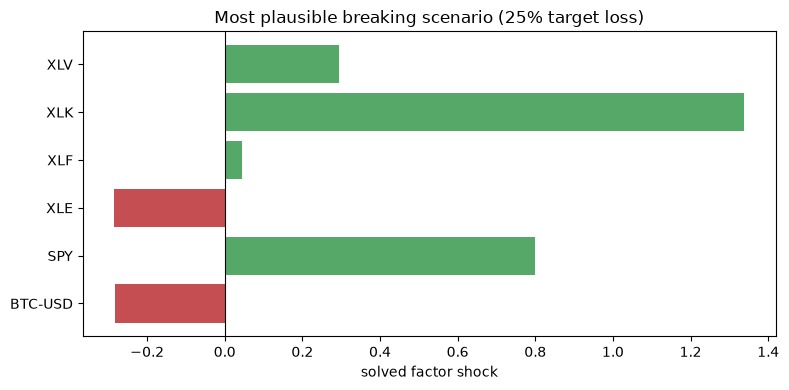

In [15]:
from reverse_stress.optimization import solve_reverse_stress

gross = total.gross_market_value
rs_result = solve_reverse_stress(portfolio_fit.loadings, portfolio_fit.alpha, factor_returns, gross * 0.25)

print(f"Target loss: ${gross * 0.25:,.2f} (25% of gross exposure)")
print(f"Mahalanobis distance: {rs_result.mahalanobis_distance:.1f} SD  (implied probability: {rs_result.implied_annual_probability:.2%})")
print("\nSolved factor shocks (~1 month horizon):")
for factor, shock in rs_result.factor_shocks.items():
    print(f"  {factor:12s} {shock:+.1%}")

fig, ax = plt.subplots(figsize=(8, 4))
factors, shocks = zip(*rs_result.factor_shocks.items())
bar_colors = ["#C44E52" if s < 0 else "#55A868" for s in shocks]
ax.barh(factors, shocks, color=bar_colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("solved factor shock")
ax.set_title("Most plausible breaking scenario (25% target loss)")
plt.tight_layout()
plt.show()

## 12. Counterparty & credit risk

CVA and concentration by venue — a genuinely different risk lens (who you're trading with defaulting, not the market moving against you).

In [16]:
from credit.cva import compute_cva
from credit.concentration import check_concentration

cva = compute_cva(valued.positions)
print(f"Total CVA: ${cva.total_cva:,.2f}")
for cp, detail in cva.by_counterparty.items():
    print(f"  {cp:12s} net_exposure=${detail['net_exposure']:>10,.2f}  PD={detail['annualized_pd']:.2%}  CVA=${detail['cva']:.2f}")

concentration = check_concentration(valued.positions)
print(f"\nConcentration (real venues only), HHI={concentration.herfindahl_index:.3f}")
for cp, share in concentration.shares.items():
    flag = " *** FLAGGED ***" if cp in concentration.flagged else ""
    print(f"  {cp:12s} {share:.1%}{flag}")

Total CVA: $34.85
  alpaca       net_exposure=$  1,114.69  PD=0.10%  CVA=$0.67
  binance      net_exposure=$  2,848.22  PD=2.00%  CVA=$34.18
  none         net_exposure=$ -6,635.64  PD=0.00%  CVA=$0.00

Concentration (real venues only), HHI=0.596
  alpaca       28.1%
  binance      71.9% *** FLAGGED ***


## 13. Extreme value theory — regime-conditional tail shape

Does the GPD tail SHAPE (not just VaR level) differ by regime? Fit at 80% threshold (90% leaves every regime bucket unfittable — too few exceedances).

In [17]:
from extreme_value.tail_risk import fit_gpd_by_regime, compare_tail_shape

evt_comparison = fit_gpd_by_regime(pnl_series, regime_labels, threshold_quantile=0.80)
for note in evt_comparison.notes:
    print(note)
compare_tail_shape(evt_comparison)

,xi,beta,n_exceedances,threshold
pooled,0.07,"3,325.16",100.00,"3,132.28"
volatile,0.06,"4,133.64",32.00,"3,042.81"
normal,0.18,"2,674.02",32.00,"3,219.83"
calm,-0.31,"4,510.43",32.00,"2,885.04"


## 14. Liquidity-adjusted VaR & concentration limits

Adds an estimated unwind cost (execedge's own square-root-law market-impact model) on top of VaR, and checks name/strategy/sector concentration limits.

In [18]:
from liquidity.impact import fetch_avg_daily_dollar_volume, liquidity_adjusted_var
from liquidity.concentration import check_by_name, check_by_sector, check_by_strategy

daily_vol = returns_df.std().to_dict()
dollar_volume = fetch_avg_daily_dollar_volume(tickers)
base_var = historical_simulation(pnl_series).var_dollar
adjusted_var, liq_costs, _ = liquidity_adjusted_var(base_var, valued.positions, daily_vol, dollar_volume)
print(f"Base VaR: ${base_var:,.2f}  ->  liquidity-adjusted: ${adjusted_var:,.2f}  (+${adjusted_var - base_var:,.2f})")

for label, check_fn in [("name", check_by_name), ("strategy", check_by_strategy), ("sector", check_by_sector)]:
    result = check_fn(valued.positions)
    flagged = result.flagged if result.total_exposure else []
    print(f"\nBy {label} (threshold={result.threshold:.0%}): flagged={flagged}")
    for key, share in sorted(result.shares.items(), key=lambda kv: -kv[1])[:5]:
        print(f"  {key:20s} {share:.1%}")

Base VaR: $7,594.01  ->  liquidity-adjusted: $7,799.69  (+$205.68)

By name (threshold=20%): flagged=['AXP', 'WFC']
  AXP                  46.8%
  WFC                  45.5%
  AVGO                 0.7%
  MPC                  0.7%
  VLO                  0.7%

By strategy (threshold=50%): flagged=['pairtrade-lab-1']
  pairtrade-lab-1      92.3%
  alpha-signal-lab     6.9%
  bookmaker            0.4%
  voledge              0.3%

By sector (threshold=40%): flagged=['Financials']
  Financials           92.3%
  Energy               3.6%
  Technology           2.0%
  Healthcare           1.4%
  unclassified         0.7%


## 15. P&L attribution

Decomposes recent P&L into per-factor and per-strategy dollar contributions, reconciling exactly to the total.

Total P&L over last 63 days: $11,223.58
Reconciles exactly: True


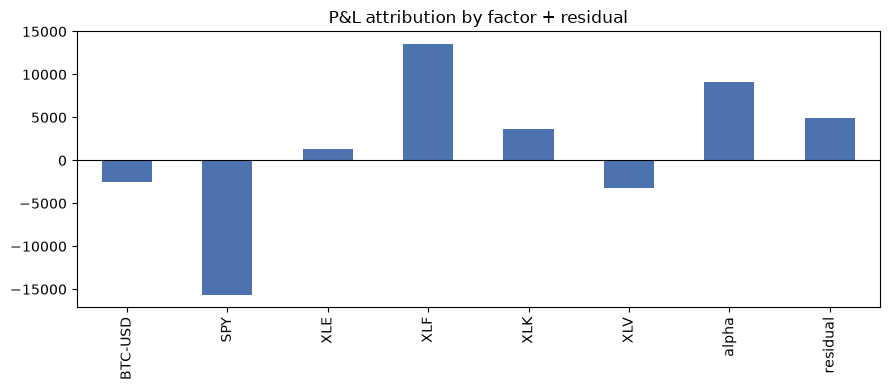

In [19]:
from attribution.pnl import attribute_by_factor
from attribution.strategy import attribute_by_strategy

RECENT_WINDOW_DAYS = 63
recent_pnl = pnl_series.iloc[-RECENT_WINDOW_DAYS:]
attribution_result = attribute_by_factor(recent_pnl, factor_returns, portfolio_fit.loadings, portfolio_fit.alpha)

print(f"Total P&L over last {RECENT_WINDOW_DAYS} days: ${attribution_result.cumulative_total:,.2f}")
print(f"Reconciles exactly: {attribution_result.reconciles()}")
attribution_summary = pd.Series({**attribution_result.cumulative_by_factor,
                                  "alpha": attribution_result.cumulative_alpha,
                                  "residual": attribution_result.cumulative_residual})
attribution_summary.plot(kind="bar", figsize=(9, 4), color="#4C72B0", title="P&L attribution by factor + residual")
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

In [20]:
by_strategy_pnl = attribute_by_strategy(valued.positions, returns_df)
{k: float(v.iloc[-RECENT_WINDOW_DAYS:].sum()) for k, v in by_strategy_pnl.items()}

{'alpha-signal-lab': 1663.880308295111,
 'bookmaker': -552.0114019002185,
 'pairtrade-lab-1': 9978.570365958301,
 'voledge': 133.1403128305809}

## 16. VaR backtesting — Kupiec + Christoffersen

Formal statistical tests of whether the pooled and regime-conditional models are actually calibrated.

In [21]:
from risk_measures.backtesting import pooled_breach_series, regime_conditional_breach_series, backtest_breach_series

pooled_result = backtest_breach_series(pooled_breach_series(pnl_series, 0.95), 0.95, "pooled")
conditional_breaches, backtest_notes = regime_conditional_breach_series(pnl_series, regime_labels, 0.95)
conditional_result = backtest_breach_series(conditional_breaches, 0.95, "regime-conditional")

for note in backtest_notes:
    print(note)
pd.DataFrame([
    {"model": r.model_label, "breaches": r.n_breaches, "kupiec_p": r.kupiec_p_value,
     "christoffersen_p": r.christoffersen_p_value, "combined_p": r.combined_p_value, "well_calibrated": r.well_calibrated}
    for r in (pooled_result, conditional_result)
]).set_index("model")

,breaches,kupiec_p,christoffersen_p,combined_p,well_calibrated
model,,,,,
pooled,25,1.00,0.51,0.81,True
regime-conditional,24,0.84,0.45,0.74,True


## 17. Live risk monitoring

Selects whichever regime-conditional VaR model currently applies, checks market-risk and credit-risk limits independently, and reports kill-switch state (read-only here — resetting requires the CLI, `python -m monitor.live --reset`, deliberately not exposed as an API call).

In [22]:
from monitor.limits import check_var_limit, check_credit_concentration_limit
from monitor.kill_switch import load_state

current_regime = regime_labels.dropna().iloc[-1]
live_conditional = compare_pooled_vs_conditional(pnl_series, returns_df, regime_labels)
if current_regime in live_conditional.conditional_var:
    active_var = live_conditional.conditional_var[current_regime]["historical_simulation"].var_dollar
    model_label = f"{current_regime}-conditional"
else:
    active_var = live_conditional.pooled_var["historical_simulation"].var_dollar
    model_label = "pooled"

var_check = check_var_limit(active_var, gross)
credit_check = check_credit_concentration_limit(valued.positions)
kill_switch = load_state()

print(f"Current regime: {current_regime}  |  active model: {model_label}  |  VaR: ${active_var:,.2f}")
print(f"  {var_check.detail}")
print(f"  {credit_check.detail}")
print(f"\nKill-switch triggered: {kill_switch.triggered}")
for reason in kill_switch.trigger_reasons:
    print(f"  - {reason}")

Current regime: normal  |  active model: normal-conditional  |  VaR: $6,110.22
  VaR is 0.86% of gross exposure (limit 5%)
  Counterparty concentration breached: ['binance'] (HHI=0.596)

Kill-switch triggered: True
  - Counterparty concentration breached: ['binance'] (HHI=0.596)


## 18. The capstone's central question

**Is this six-project book actually as diversified as each project's own backtest implied, or does aggregation reveal real hidden risk?**

No — and it's not one finding, it's four independent methodologies (factor decomposition, position aggregation, concentration limits, P&L attribution) all converging on the same root cause: pairtrade-lab-1's "market-neutral" pairs book carries real, statistically significant hidden market beta once aggregated with real position sizing, and its outsized current position dominates the book's gross exposure, concentration limits, and recent P&L alike. Reverse stress testing shows the direct consequence: the scenario that would actually break this book — a rally, not a crash — is not one any individual strategy's own risk process would ever surface, because none of the six source repos model cross-strategy aggregation at all.

See the README's own "Results & Honest Comparison" section for the full write-up, every caveat, and the necessary nuance: this magnitude is specific to pairtrade-lab-1's current thin stand-in snapshot, and alpha-signal-lab alone looks well-diversified in isolation — this is a real, fixable finding about one strategy's current sizing, not a blanket indictment of the whole portfolio.